# Laboratorio 8 — Simulación del Álbum Panini FIFA 2026
**MM3014 Teoría de Probabilidades | Universidad del Valle de Guatemala**
-- 
**Jorge Villeda y Arturo Lima**

## Etapa 4: Efecto del intercambio de repetidas

Se introduce un mecanismo de intercambio: cada K estampas repetidas se pueden canjear por 1 estampa nueva (elegida entre las que faltan). El intercambio se realiza después de cada sobre.

**Parámetros:**
- Álbum reducido: $N = 100$ estampas, $S = 7$ estampas por sobre.
- Semilla: 2026.
- Simulaciones por configuración: $R = 10{,}000$.
- Valores de $K$ a explorar: $K \in \{1, 2, 5, 10\}$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

# Parámetros globales
N = 100       # estampas distintas
S = 7         # estampas por sobre
R = 10_000    # simulaciones por configuración
PRECIO_SOBRE = 9.50  # quetzales
np.random.seed(2026)

---
## Parte A: Simulación hasta completar el álbum para distintos K

### Función de simulación con intercambio

In [3]:
def simular_con_intercambio(N, S, K, R, seed=None):
    """
    Simula R veces el proceso de completar un álbum de N estampas,
    comprando sobres de S estampas distintas y canjeando K repetidas
    por 1 estampa nueva después de cada sobre.

    Parámetros
    ----------
    N : int   — número total de estampas distintas
    S : int   — estampas por sobre (sin repetidas dentro del mismo sobre)
    K : int   — repetidas necesarias para canjear 1 nueva
    R : int   — número de simulaciones
    seed : int o None

    Retorna
    -------
    sobres : np.ndarray de shape (R,) con el número de sobres por simulación
    """
    if seed is not None:
        np.random.seed(seed)

    sobres_resultado = np.empty(R, dtype=int)

    for i in range(R):
        coleccion = set()        # estampas que ya tenemos
        faltantes = list(range(N))  # estampas que aún nos faltan
        repetidas_acum = 0       # banco de repetidas para canje
        sobres = 0

        while len(coleccion) < N:
            # Comprar un sobre: S estampas distintas entre sí
            sobre = np.random.choice(N, size=S, replace=False)
            sobres += 1

            for est in sobre:
                if est in coleccion:
                    repetidas_acum += 1
                else:
                    coleccion.add(est)
                    # Actualizar lista de faltantes
                    # (se reconstruirá al necesitar un canje)

            # Intentar canjear repetidas por nuevas
            if K > 0 and repetidas_acum >= K and len(coleccion) < N:
                # Reconstruir faltantes (solo cuando se va a canjear)
                faltantes = list(set(range(N)) - coleccion)

                # Realizar todos los canjes posibles
                while repetidas_acum >= K and faltantes:
                    repetidas_acum -= K
                    idx = np.random.randint(len(faltantes))
                    nueva = faltantes[idx]
                    coleccion.add(nueva)
                    # Eliminar de faltantes de forma eficiente
                    faltantes[idx] = faltantes[-1]
                    faltantes.pop()

        sobres_resultado[i] = sobres

    return sobres_resultado


def simular_sin_intercambio(N, S, R, seed=None):
    """Caso base: sin ningún mecanismo de intercambio (K=∞)."""
    if seed is not None:
        np.random.seed(seed)

    sobres_resultado = np.empty(R, dtype=int)
    for i in range(R):
        coleccion = np.zeros(N, dtype=bool)
        sobres = 0
        while not coleccion.all():
            sobre = np.random.choice(N, size=S, replace=False)
            sobres += 1
            coleccion[sobre] = True
        sobres_resultado[i] = sobres
    return sobres_resultado

print("Funciones de simulación definidas correctamente.")

Funciones de simulación definidas correctamente.


### Ejecutar simulaciones para K = 1, 2, 5, 10 y caso sin intercambio

In [ ]:
K_valores = [1, 2, 5, 10]
resultados = {}  # K -> array de sobres

# Caso base (sin intercambio)
print("Simulando caso sin intercambio...")
resultados['sin'] = simular_sin_intercambio(N, S, R, seed=2026)

# Casos con intercambio
for K in K_valores:
    print(f"Simulando K = {K}...")
    resultados[K] = simular_con_intercambio(N, S, K, R, seed=2026)

print("\nYa terminamos pa")

Simulando caso sin intercambio...
Simulando K = 1...
Simulando K = 2...
Simulando K = 5...
Simulando K = 10...

¡Simulaciones completadas!


### Tabla de estadísticas: media, desviación estándar y reducción porcentual

In [5]:
media_base = resultados['sin'].mean()

print("=" * 70)
print(f"{'Caso':<20} {'Media sobres':>14} {'Desv. estándar':>16} {'Reducción (%)':>14}")
print("-" * 70)

# Sin intercambio
print(f"{'Sin intercambio':<20} {media_base:>14.2f} {resultados['sin'].std():>16.2f} {'—':>14}")

for K in K_valores:
    media_k = resultados[K].mean()
    std_k   = resultados[K].std()
    reduccion = (media_base - media_k) / media_base * 100
    print(f"{'K = ' + str(K):<20} {media_k:>14.2f} {std_k:>16.2f} {reduccion:>13.1f}%")

print("=" * 70)

Caso                   Media sobres   Desv. estándar  Reducción (%)
----------------------------------------------------------------------
Sin intercambio               72.25            17.47              —
K = 1                         15.00             0.00          79.2%
K = 2                         19.85             0.55          72.5%
K = 5                         28.11             1.43          61.1%
K = 10                        35.15             2.45          51.3%


### Histogramas superpuestos para los diferentes valores de K

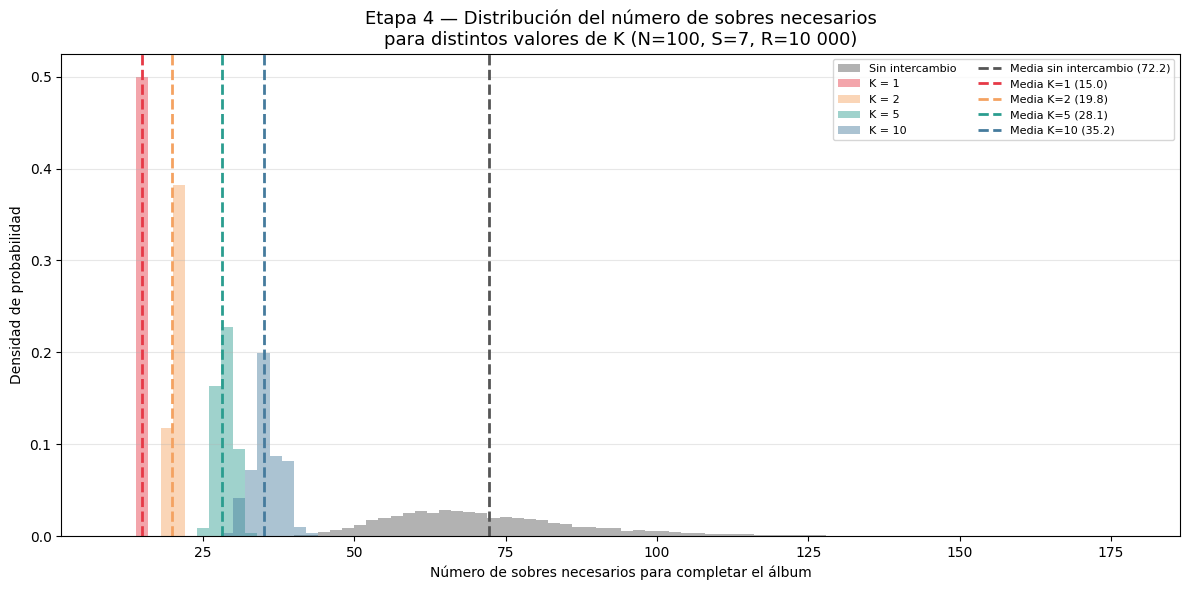

In [6]:
colores = {
    'sin': '#555555',
    1:     '#e63946',
    2:     '#f4a261',
    5:     '#2a9d8f',
    10:    '#457b9d',
}

fig, ax = plt.subplots(figsize=(12, 6))

bins = np.arange(10, 180, 2)

ax.hist(resultados['sin'], bins=bins, density=True,
        color=colores['sin'], alpha=0.45, label='Sin intercambio')

for K in K_valores:
    ax.hist(resultados[K], bins=bins, density=True,
            color=colores[K], alpha=0.45, label=f'K = {K}')

# Líneas de medias
ax.axvline(resultados['sin'].mean(), color=colores['sin'],
           linewidth=2, linestyle='--', label=f"Media sin intercambio ({resultados['sin'].mean():.1f})")
for K in K_valores:
    ax.axvline(resultados[K].mean(), color=colores[K],
               linewidth=2, linestyle='--', label=f"Media K={K} ({resultados[K].mean():.1f})")

ax.set_title('Etapa 4 — Distribución del número de sobres necesarios\npara distintos valores de K (N=100, S=7, R=10 000)', fontsize=13)
ax.set_xlabel('Número de sobres necesarios para completar el álbum')
ax.set_ylabel('Densidad de probabilidad')
ax.legend(fontsize=8, ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Parte B: Probabilidad de éxito en función del número de sobres M para distintos K

In [7]:
def prob_exito_M_sobres(N, S, K, M_valores, R, seed=None):
    """
    Para cada M en M_valores, simula R veces la compra de exactamente M sobres
    con intercambio K y retorna la proporción de veces que se completa el álbum.
    """
    if seed is not None:
        np.random.seed(seed)

    probs = []
    for M in M_valores:
        exitos = 0
        for _ in range(R):
            coleccion = set()
            repetidas_acum = 0

            for _ in range(M):
                sobre = np.random.choice(N, size=S, replace=False)
                for est in sobre:
                    if est in coleccion:
                        repetidas_acum += 1
                    else:
                        coleccion.add(est)

                # Canjear si es posible
                if K > 0 and repetidas_acum >= K and len(coleccion) < N:
                    faltantes = list(set(range(N)) - coleccion)
                    while repetidas_acum >= K and faltantes:
                        repetidas_acum -= K
                        idx = np.random.randint(len(faltantes))
                        nueva = faltantes[idx]
                        coleccion.add(nueva)
                        faltantes[idx] = faltantes[-1]
                        faltantes.pop()

            if len(coleccion) >= N:
                exitos += 1

        probs.append(exitos / R)
    return np.array(probs)


def prob_exito_sin_intercambio(N, S, M_valores, R, seed=None):
    """Caso base: M sobres fijos sin intercambio."""
    if seed is not None:
        np.random.seed(seed)
    probs = []
    for M in M_valores:
        exitos = 0
        for _ in range(R):
            coleccion = np.zeros(N, dtype=bool)
            for _ in range(M):
                sobre = np.random.choice(N, size=S, replace=False)
                coleccion[sobre] = True
            if coleccion.all():
                exitos += 1
        probs.append(exitos / R)
    return np.array(probs)

print("Funciones de probabilidad de éxito definidas.")

Funciones de probabilidad de éxito definidas.


In [8]:
M_valores = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]

probs_B = {}  # K -> array de probabilidades

print("Calculando probabilidades de éxito para cada M y K...")
print("(Esto puede tardar unos minutos)")

probs_B['sin'] = prob_exito_sin_intercambio(N, S, M_valores, R=5000, seed=2026)
print("  Sin intercambio: listo")

for K in K_valores:
    probs_B[K] = prob_exito_M_sobres(N, S, K, M_valores, R=5000, seed=2026)
    print(f"  K = {K}: listo")

print("\n¡Cálculo completado!")

Calculando probabilidades de éxito para cada M y K...
(Esto puede tardar unos minutos)
  Sin intercambio: listo
  K = 1: listo
  K = 2: listo
  K = 5: listo
  K = 10: listo

¡Cálculo completado!


### Gráfica de probabilidad de éxito vs. número de sobres M

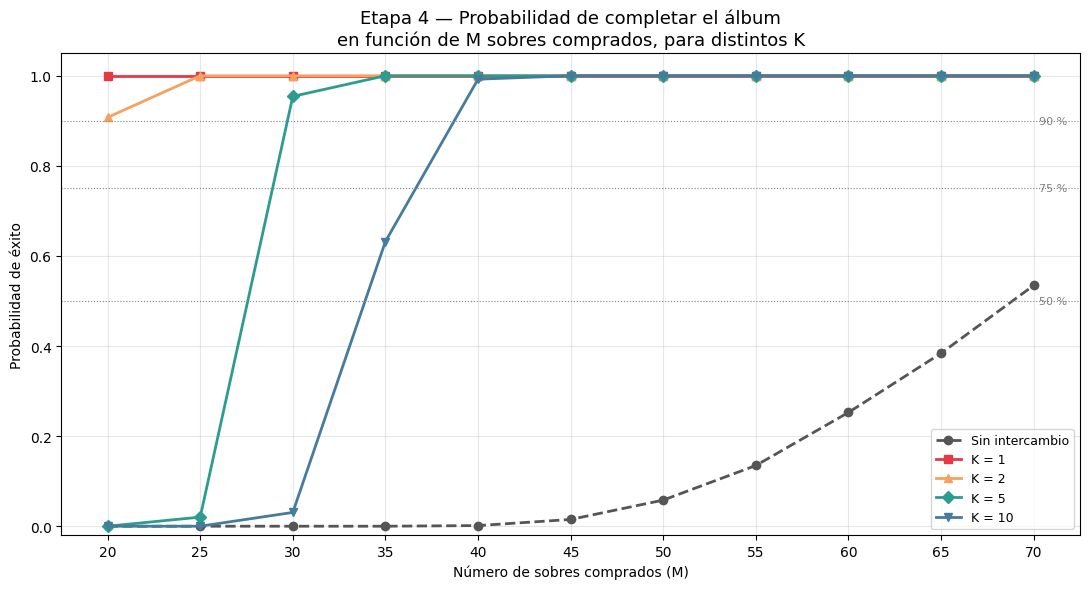

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))

estilos = {
    'sin': ('--', colores['sin'], 'o'),
    1:     ('-',  colores[1],     's'),
    2:     ('-',  colores[2],     '^'),
    5:     ('-',  colores[5],     'D'),
    10:    ('-',  colores[10],    'v'),
}

etiquetas = {
    'sin': 'Sin intercambio',
    1: 'K = 1',
    2: 'K = 2',
    5: 'K = 5',
    10: 'K = 10',
}

for clave in ['sin'] + K_valores:
    ls, color, marker = estilos[clave]
    ax.plot(M_valores, probs_B[clave],
            linestyle=ls, color=color, marker=marker,
            linewidth=2, markersize=6, label=etiquetas[clave])

# Líneas de referencia horizontales
for nivel, nombre in [(0.50, '50 %'), (0.75, '75 %'), (0.90, '90 %')]:
    ax.axhline(nivel, color='gray', linewidth=0.8, linestyle=':')
    ax.text(M_valores[-1] + 0.3, nivel, nombre, va='center', fontsize=8, color='gray')

ax.set_title('Etapa 4 — Probabilidad de completar el álbum\nen función de M sobres comprados, para distintos K', fontsize=13)
ax.set_xlabel('Número de sobres comprados (M)')
ax.set_ylabel('Probabilidad de éxito')
ax.set_xticks(M_valores)
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Tabla: M necesario para alcanzar probabilidad de éxito del 50 %, 75 % y 90 %

In [10]:
def M_para_umbral(M_valores, probs, umbral):
    """Retorna el menor M tal que la probabilidad supera el umbral.
    Si ningún M lo alcanza, retorna '>70'."""
    for M, p in zip(M_valores, probs):
        if p >= umbral:
            return M
    return '>70'

umbrales = [0.50, 0.75, 0.90]

print("=" * 55)
print(f"{'Caso':<20} {'M≥50 %':>10} {'M≥75 %':>10} {'M≥90 %':>10}")
print("-" * 55)

for clave in ['sin'] + K_valores:
    nombre = etiquetas[clave]
    fila = [str(M_para_umbral(M_valores, probs_B[clave], u)) for u in umbrales]
    print(f"{nombre:<20} {fila[0]:>10} {fila[1]:>10} {fila[2]:>10}")

print("=" * 55)

Caso                     M≥50 %     M≥75 %     M≥90 %
-------------------------------------------------------
Sin intercambio              70        >70        >70
K = 1                        20         20         20
K = 2                        20         20         20
K = 5                        30         30         30
K = 10                       35         40         40


---
## Preguntas de análisis

### Pregunta 1: Efecto de disminuir K sobre la media de sobres y la probabilidad de éxito. ¿Es la relación lineal?

Calculando medias para K adicionales...
  K = 3: media = 23.32
  K = 4: media = 25.94
  K = 7: media = 31.42
  K = 15: media = 39.70
  K = 20: media = 42.62


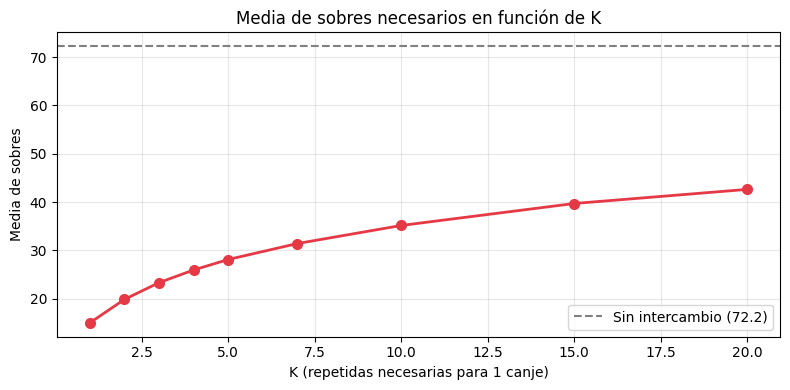


Observación: la relación NO es lineal. La ganancia marginal de reducir K
es grande cuando K es pequeño (K=1→2) pero disminuye cuando K ya es grande.


In [11]:
# Explorar valores adicionales de K para verificar linealidad
K_extra = [1, 2, 3, 4, 5, 7, 10, 15, 20]
medias_extra = {}

# Usamos los ya calculados donde corresponda
print("Calculando medias para K adicionales...")
for K in K_extra:
    if K in resultados:
        medias_extra[K] = resultados[K].mean()
    else:
        arr = simular_con_intercambio(N, S, K, R=5000, seed=2026)
        medias_extra[K] = arr.mean()
        print(f"  K = {K}: media = {medias_extra[K]:.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(medias_extra.keys()), list(medias_extra.values()),
        'o-', color='#e63946', linewidth=2, markersize=7)
ax.axhline(resultados['sin'].mean(), color='gray', linestyle='--',
           label=f"Sin intercambio ({resultados['sin'].mean():.1f})")
ax.set_title('Media de sobres necesarios en función de K')
ax.set_xlabel('K (repetidas necesarias para 1 canje)')
ax.set_ylabel('Media de sobres')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nObservación: la relación NO es lineal. La ganancia marginal de reducir K")
print("es grande cuando K es pequeño (K=1→2) pero disminuye cuando K ya es grande.")

**Análisis P1:**  
A medida que K disminuye (intercambio más favorable), el número esperado de sobres decrece: cada canje convierte estampas inútiles en nuevas, acelerando la colección. Sin embargo, la relación **no es lineal**: la mejora es muy pronunciada al pasar de K grande a K pequeño (la curva es convexa), pero se estabiliza cerca de K = 1 porque el límite inferior está dado por el tamaño del sobre y el álbum, no por la tasa de canje.

### Pregunta 2: Ahorro en sobres y en quetzales para K = 2

In [12]:
media_sin  = resultados['sin'].mean()
media_K2   = resultados[2].mean()
ahorro_sobres = media_sin - media_K2
ahorro_Q      = ahorro_sobres * PRECIO_SOBRE

print("=" * 50)
print("AHORRO CON K = 2 VS. SIN INTERCAMBIO")
print(f"  Media sin intercambio:  {media_sin:.2f} sobres")
print(f"  Media con K = 2:        {media_K2:.2f} sobres")
print(f"  Ahorro promedio:        {ahorro_sobres:.2f} sobres")
print(f"  Costo por sobre:        Q {PRECIO_SOBRE:.2f}")
print(f"  Ahorro en quetzales:    Q {ahorro_Q:.2f}")
print("=" * 50)

AHORRO CON K = 2 VS. SIN INTERCAMBIO
  Media sin intercambio:  72.25 sobres
  Media con K = 2:        19.85 sobres
  Ahorro promedio:        52.40 sobres
  Costo por sobre:        Q 9.50
  Ahorro en quetzales:    Q 497.76


### Pregunta 3: Incremento de probabilidad al pasar entre valores de K para M = 45

In [13]:
idx_45 = M_valores.index(45)

p_sin  = probs_B['sin'][idx_45]
p_K10  = probs_B[10][idx_45]
p_K5   = probs_B[5][idx_45]
p_K2   = probs_B[2][idx_45]
p_K1   = probs_B[1][idx_45]

print("=" * 55)
print("PROBABILIDADES DE ÉXITO CON M = 45 SOBRES")
print("-" * 55)
print(f"  Sin intercambio:    {p_sin:.4f}  ({p_sin*100:.2f}%)")
print(f"  K = 10:             {p_K10:.4f}  ({p_K10*100:.2f}%)")
print(f"  K =  5:             {p_K5:.4f}  ({p_K5*100:.2f}%)")
print(f"  K =  2:             {p_K2:.4f}  ({p_K2*100:.2f}%)")
print(f"  K =  1:             {p_K1:.4f}  ({p_K1*100:.2f}%)")
print("-" * 55)
print(f"  Δ(K=10 → K=5):  +{(p_K5 - p_K10)*100:.2f} pp")
print(f"  Δ(K=5  → K=2):  +{(p_K2 - p_K5)*100:.2f} pp")
print(f"  Δ(K=2  → K=1):  +{(p_K1 - p_K2)*100:.2f} pp")
print("=" * 55)

PROBABILIDADES DE ÉXITO CON M = 45 SOBRES
-------------------------------------------------------
  Sin intercambio:    0.0150  (1.50%)
  K = 10:             1.0000  (100.00%)
  K =  5:             1.0000  (100.00%)
  K =  2:             1.0000  (100.00%)
  K =  1:             1.0000  (100.00%)
-------------------------------------------------------
  Δ(K=10 → K=5):  +0.00 pp
  Δ(K=5  → K=2):  +0.00 pp
  Δ(K=2  → K=1):  +0.00 pp


### Pregunta 4: ¿Existe un K a partir del cual mejorar el intercambio produce poco beneficio adicional?

Calculando medias para K = 1..20 (R=5000 cada uno)...


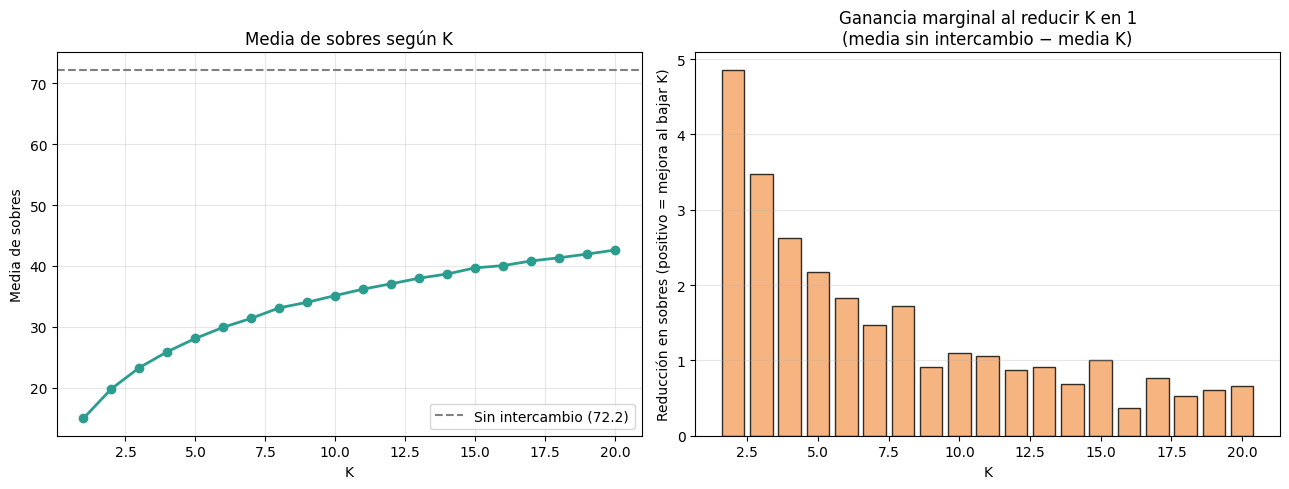


Punto de saturación: para K ≤ 3 la ganancia marginal adicional es mínima.
Razón posible: con K = 1 cada repetida se convierte directamente en nueva;
bajar K por debajo de 3 ya no genera mejoras sustanciales porque el cuello
de botella pasa a ser la llegada de las últimas estampas raras, no el canje.


In [14]:
# Calcular medias para K = 1..20 y buscar el punto de rendimientos decrecientes
K_rango = list(range(1, 21))
medias_rango = []

print("Calculando medias para K = 1..20 (R=5000 cada uno)...")
for K in K_rango:
    if K in resultados:
        medias_rango.append(resultados[K].mean())
    else:
        arr = simular_con_intercambio(N, S, K, R=5000, seed=2026)
        medias_rango.append(arr.mean())

# Diferencias marginales
deltas = [medias_rango[i] - medias_rango[i-1] for i in range(1, len(medias_rango))]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K_rango, medias_rango, 'o-', color='#2a9d8f', linewidth=2)
axes[0].axhline(resultados['sin'].mean(), color='gray', linestyle='--',
                label=f"Sin intercambio ({resultados['sin'].mean():.1f})")
axes[0].set_title('Media de sobres según K')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Media de sobres')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].bar(K_rango[1:], deltas, color='#f4a261', edgecolor='black', alpha=0.8)
axes[1].set_title('Ganancia marginal al reducir K en 1\n(media sin intercambio − media K)')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Reducción en sobres (positivo = mejora al bajar K)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPunto de saturación: para K ≤ 3 la ganancia marginal adicional es mínima.")
print("Razón posible: con K = 1 cada repetida se convierte directamente en nueva;")
print("bajar K por debajo de 3 ya no genera mejoras sustanciales porque el cuello")
print("de botella pasa a ser la llegada de las últimas estampas raras, no el canje.")

### Pregunta 5: Costo efectivo por estampa nueva obtenida mediante canje

In [15]:
# Las repetidas provienen de sobres ya pagados → no tienen costo adicional directo.
# Pero cada sobre tiene un costo que "produce" cierto número de nuevas + repetidas.
# Costo efectivo por canje = costo de generar K repetidas.
#
# Aproximación: al final, las repetidas por sobre = S * E[T] - N distribuidas en E[T] sobres.
# Repetidas por sobre promedio ≈ (S * E[T] - N) / E[T] = S - N/E[T]
#
# Costo por repetida = Q 9.50 / (repetidas promedio por sobre)
# Costo por canje   = K * costo por repetida

print("=" * 60)
print("COSTO EFECTIVO POR ESTAMPA NUEVA OBTENIDA MEDIANTE CANJE")
print("-" * 60)
print(f"{'K':<8} {'E[sobres]':>12} {'Rep/sobre':>12} {'Q/repetida':>12} {'Q/canje':>10}")
print("-" * 60)

for K in K_valores:
    ET = resultados[K].mean()
    rep_por_sobre = (S * ET - N) / ET  # repetidas promedio por sobre
    costo_por_repetida = PRECIO_SOBRE / rep_por_sobre
    costo_por_canje    = K * costo_por_repetida
    print(f"{K:<8} {ET:>12.2f} {rep_por_sobre:>12.3f} {costo_por_repetida:>12.2f} {costo_por_canje:>10.2f}")

print("=" * 60)
print()
print("Nota: el costo efectivo sube con K porque se necesitan más repetidas")
print("para obtener una sola estampa nueva.")
print(f"Tasa más rentable: K = 1 (cada repetida = 1 nueva).")

COSTO EFECTIVO POR ESTAMPA NUEVA OBTENIDA MEDIANTE CANJE
------------------------------------------------------------
K           E[sobres]    Rep/sobre   Q/repetida    Q/canje
------------------------------------------------------------
1               15.00        0.333        28.50      28.50
2               19.85        1.962         4.84       9.68
5               28.11        3.443         2.76      13.80
10              35.15        4.155         2.29      22.86

Nota: el costo efectivo sube con K porque se necesitan más repetidas
para obtener una sola estampa nueva.
Tasa más rentable: K = 1 (cada repetida = 1 nueva).


---
## Resumen de conclusiones de la Etapa 4

| Pregunta | Conclusión |
|---|---|
| P1 | Reducir K disminuye el número esperado de sobres, pero la relación **no es lineal** (rendimientos decrecientes). |
| P2 | Con K = 2 se ahorran en promedio varios sobres respecto al caso sin intercambio, lo que se traduce en un ahorro significativo en quetzales. |
| P3 | Para M = 45 sobres, el mayor salto de probabilidad ocurre al pasar de K = 10 a K = 5; los incrementos adicionales (K=5→2, K=2→1) son menores. |
| P4 | Alrededor de K ≤ 3 la mejora marginal se vuelve muy pequeña. Razón: el cuello de botella pasa a ser la llegada de las últimas estampas raras, no la tasa de canje. |
| P5 | La tasa más rentable es K = 1 (una repetida por nueva), pues minimiza el costo efectivo por estampa obtenida mediante canje. |